# Movie Rating Prediction — Model Training and Evaluation

**Notebook:** `03_model_training.ipynb`
**Depends on:** `src/data_preprocessing.py` (Phase 2)

## 1. Phase 3 Overview

This notebook builds the first complete training and evaluation pipeline:

```
raw CSV (read-only)
   ↓  build_modeling_frame        – row-wise cleaning, exact duplicates removed, rated rows only
modeling dataframe
   ↓  group-aware split            – groups = Name + Year, 80 / 20, random_state = 42
train rows            test rows
   ↓ fit + transform       ↓ transform only (same fitted object)
X_train                X_test
   ↓
baseline · Linear Regression · Random Forest · Gradient Boosting
   ↓
metrics on the test set, plots, error analysis
```

**Primary feature inputs:** `Year`, `Duration`, `Genre`, `Director`, `Actor 1`, `Actor 2`, `Actor 3`.
`Votes` is **not** used. Its availability at prediction time is a modeling assumption this primary experiment
deliberately does not make. `Rating` is only ever the target.

All preprocessing logic is imported from `src/data_preprocessing.py`; none of it is re-implemented here. No model is
saved to disk in this phase.

## 2. Imports and Configuration

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "dataset" / "IMDb Movies India.csv"
FIG_DIR = PROJECT_ROOT / "visualizations"
FIG_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import data_preprocessing as dp

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Plot styling (consistent with Phases 1–2): one hue per chart, baseline in neutral grey
PRIMARY = "#2a78d6"
ACCENT = "#eb6834"
NEUTRAL = "#a3a29c"
MUTED = "#52514e"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": "#c9c8c2", "axes.titleweight": "bold", "axes.titlesize": 12,
    "grid.color": "#e6e5e0", "xtick.color": MUTED, "ytick.color": MUTED,
})

## 3. Load Dataset

The loader reads the CSV with `encoding="latin-1"` (the file is not UTF-8). The file's SHA-256 checksum is compared
with the one recorded in Phase 1, before and after the experiment.

In [2]:
import hashlib

PHASE1_SHA256 = "68295a15943a675f38fe8c49af8f5d51b4b833aadb8a4da79da74b0a61c36479"
file_sha256 = lambda p: hashlib.sha256(Path(p).read_bytes()).hexdigest()
assert file_sha256(DATA_PATH) == PHASE1_SHA256, "Raw CSV differs from the Phase 1 version"

raw = dp.load_raw_data(DATA_PATH)
print(f"Raw data: {raw.shape[0]:,} rows × {raw.shape[1]} columns (checksum matches Phase 1)")

Raw data: 15,509 rows × 10 columns (checksum matches Phase 1)


## 4. Prepare Modeling Data

`build_modeling_frame` (Phase 2) applies only row-wise operations: text parsing, exact-duplicate removal and
keeping rows that have a `Rating`. It computes no cross-row statistics, so it is safe to run before splitting.
Missing ratings are **not** imputed.

In [3]:
model_df, row_log = dp.build_modeling_frame(raw)
X, y = dp.get_features_and_target(model_df)

print(pd.Series(row_log).to_string())
print(f"\nFeature inputs : {list(X.columns)}")
print(f"Target         : {y.name}  (missing: {y.isna().sum()})")

forbidden = {"Rating", "Votes", "Votes_eda"}
assert not forbidden & set(X.columns), "Target or Votes leaked into the feature inputs"
print("Rating / Votes / Votes_eda excluded from X:", not forbidden & set(X.columns))

raw_rows                        15509
exact_duplicates_removed            6
exact_duplicates_with_rating        0
rows_after_dedup                15503
unrated_rows_excluded            7584
modeling_rows                    7919

Feature inputs : ['Year', 'Duration_min', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
Target         : Rating  (missing: 0)
Rating / Votes / Votes_eda excluded from X: True


## 5. Create Group Identifier

Phase 2 found `Name` + `Year` repeats (e.g. two *Sant Dnyaneshwar (1940)* records with the same director and cast).
To keep such records on the same side of the split, each row gets a group key built from a normalised title and year:

- title: surrounding whitespace stripped, inner whitespace collapsed, case-folded
- year: integer, or `NA` if missing
- a missing or blank title gets a **unique** key based on the row's `raw_index`, so unrelated untitled rows are
  never merged into one group

In [4]:
def make_group_id(df: pd.DataFrame) -> pd.Series:
    """Group key 'normalised title|year'; blank titles get a unique per-row key."""
    title = df["Name"].fillna("").str.strip().str.replace(r"\s+", " ", regex=True).str.casefold()
    year = df["Year"].astype("Int64").astype("string").fillna("NA")
    group = title + "|" + year
    blank = title.eq("")
    group[blank] = "__untitled__|" + df.loc[blank, "raw_index"].astype(str)
    return group.rename("group_id")

groups = make_group_id(model_df)
group_sizes = groups.value_counts()
print(f"Blank titles in modeling rows : {model_df['Name'].fillna('').str.strip().eq('').sum()}")
print(f"Distinct groups               : {groups.nunique():,}")
print(f"Groups with more than one row : {(group_sizes > 1).sum()}")
model_df.assign(group_id=groups).loc[groups.isin(group_sizes[group_sizes > 1].index), ["group_id", "Name", "Year", "Director", "Rating"]]

Blank titles in modeling rows : 0
Distinct groups               : 7,916
Groups with more than one row : 3


,group_id,Name,Year,Director,Rating
3187,india's daughter|2015,India's Daughter,2015.0,Leslee Udwin,8.2
3188,india's daughter|2015,India's Daughter,2015.0,Rupesh Paul,6.9
6359,sant dnyaneshwar|1940,Sant Dnyaneshwar,1940.0,Vishnupant Govind Damle,7.9
6360,sant dnyaneshwar|1940,Sant Dnyaneshwar,1940.0,Vishnupant Govind Damle,8.1
7575,vikram|1986,Vikram,1986.0,Rajasekar,7.3
7576,vikram|1986,Vikram,1986.0,V. Madhusudan Rao,7.1


## 6. Group-Aware Train/Test Split

`GroupShuffleSplit` assigns whole groups to either train or test. `test_size=0.2` refers to the share of **groups**.
Almost every group has a single row, so the row split is also close to 80/20.

In [5]:
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

split_summary = pd.Series({
    "Total modeling rows": len(X),
    "Training rows": len(X_train),
    "Test rows": len(X_test),
    "Training share of rows": f"{len(X_train) / len(X):.1%}",
    "Training groups": groups_train.nunique(),
    "Test groups": groups_test.nunique(),
}, name="value")
split_summary.to_frame()

,value
Total modeling rows,7919
Training rows,6335
Test rows,1584
Training share of rows,80.0%
Training groups,6332
Test groups,1584


## 7. Verify No Group Leakage

In [6]:
overlap = set(groups_train) & set(groups_test)
print(f"set(train_groups) ∩ set(test_groups) = {overlap if overlap else 'set()  (empty)'}")
print(f"Group overlap count: {len(overlap)}")
assert len(overlap) == 0
assert set(train_idx).isdisjoint(test_idx) and len(train_idx) + len(test_idx) == len(X)

repeated = group_sizes[group_sizes > 1].index
print("\nWhere the repeated Name + Year groups ended up:")
pd.DataFrame({
    "group_id": repeated,
    "rows_in_train": [(groups_train == g).sum() for g in repeated],
    "rows_in_test": [(groups_test == g).sum() for g in repeated],
})

set(train_groups) ∩ set(test_groups) = set()  (empty)
Group overlap count: 0

Where the repeated Name + Year groups ended up:


,group_id,rows_in_train,rows_in_test
0,india's daughter|2015,2,0
1,sant dnyaneshwar|1940,2,0
2,vikram|1986,2,0


In [7]:
print("Target distribution in each split (should be similar):")
pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).T.round(3)

Target distribution in each split (should be similar):


,count,mean,std,min,25%,50%,75%,max
train,6335.0,5.834,1.379,1.1,4.9,6.0,6.8,10.0
test,1584.0,5.873,1.391,1.6,4.9,6.0,6.9,9.7


## 8. Fit Training-Only Preprocessor

`build_feature_transformer()` returns an **unfitted** transformer (Phase 2). It is fitted **only on `X_train`**. All
the statistics it learns come from the training rows alone:

- the Year median fallback and the per-decade Duration medians
- the genre vocabulary
- director and actor film counts, and which names are frequent enough for their own column

It never receives `y`.

In [8]:
preprocessor = dp.build_feature_transformer()
preprocessor.fit(X_train)  # training rows only; no target passed

numeric_step = preprocessor.named_transformers_["numeric"]
director_step = preprocessor.named_transformers_["director"]
actor_step = preprocessor.named_transformers_["actors"]
genre_step = preprocessor.named_transformers_["genre"]

print(f"Year median (train)             : {numeric_step.year_median_}")
print(f"Duration median (train)         : {numeric_step.duration_median_}")
print(f"Duration decade medians (train) : {numeric_step.duration_decade_medians_}")
print(f"Genre vocabulary size           : {len(genre_step.vocabulary_)}")
print(f"Directors counted / one-hot     : {len(director_step.name_counts_):,} / {len(director_step.frequent_names_)}")
print(f"Actors counted / multi-hot      : {len(actor_step.name_counts_):,} / {len(actor_step.frequent_names_)}")

Year median (train)             : 1997.0
Duration median (train)         : 135.0
Duration decade medians (train) : {1930.0: 142.5, 1940.0: 137.5, 1950.0: 142.5, 1960.0: 146.0, 1970.0: 137.0, 1980.0: 140.0, 1990.0: 148.0, 2000.0: 135.0, 2010.0: 120.0, 2020.0: 111.0}
Genre vocabulary size           : 22
Directors counted / one-hot     : 2,691 / 113
Actors counted / multi-hot      : 5,271 / 173


**Proof that the statistics come from training data only.** The director counts learned by the transformer are
recomputed by hand from `X_train` and compared. Directors that appear **only** in the test set must be absent from
the fitted vocabulary.

In [9]:
manual_director_counts = X_train["Director"].dropna().value_counts().to_dict()
print("Fitted director counts == counts from X_train only:", director_step.name_counts_ == manual_director_counts)

test_only_directors = set(X_test["Director"].dropna()) - set(X_train["Director"].dropna())
leaked = test_only_directors & set(director_step.name_counts_)
print(f"Directors appearing only in the test set: {len(test_only_directors):,}; present in fitted counts: {len(leaked)}")

manual_duration_median = float(pd.to_numeric(X_train["Duration_min"], errors="coerce").median())
print("Fitted Duration median == X_train median:", numeric_step.duration_median_ == manual_duration_median)

assert director_step.name_counts_ == manual_director_counts and not leaked
assert numeric_step.duration_median_ == manual_duration_median

Fitted director counts == counts from X_train only: True
Directors appearing only in the test set: 448; present in fitted counts: 0
Fitted Duration median == X_train median: True


## 9. Transform Train and Test

The **same fitted object** transforms both sets. The test set is only passed to `transform`, never to `fit`.

In [10]:
Xt_train = preprocessor.transform(X_train)
Xt_test = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print(f"Transformed training matrix: {Xt_train.shape}")
print(f"Transformed test matrix    : {Xt_test.shape}")

feature_groups = pd.Series({
    name: len(step.get_feature_names_out()) for name, step, _ in preprocessor.transformers_ if name != "remainder"
}, name="columns")
feature_groups["total"] = feature_groups.sum()
feature_groups.to_frame()

Transformed training matrix: (6335, 322)
Transformed test matrix    : (1584, 322)


,columns
numeric,3
genre,24
director,115
actors,180
total,322


In [11]:
Xt_train.iloc[:5, :12]

,Year,Duration_min,duration_missing,genre=Action,genre=Adventure,genre=Animation,genre=Biography,genre=Comedy,genre=Crime,genre=Documentary,genre=Drama,genre=Family
1,2019.0,110.0,0,0,0,0,0,1,0,0,0,0
2,1997.0,147.0,0,0,0,0,0,1,0,0,1,0
3,2005.0,142.0,0,0,0,0,0,0,0,0,1,0
5,2014.0,116.0,0,1,0,0,0,0,1,0,0,0
6,2004.0,96.0,0,0,0,0,0,0,0,0,1,0


## 10. Validate Feature Matrices

The transformer returns dense pandas DataFrames (a few hundred integer or float columns), so they can be checked
directly without densifying a sparse matrix.

In [12]:
def matrix_checks(name, M):
    values = M.to_numpy(dtype=float)
    return {
        "matrix": name,
        "rows": M.shape[0],
        "columns": M.shape[1],
        "NaN values": int(np.isnan(values).sum()),
        "infinite values": int(np.isinf(values).sum()),
        "all numeric": all(pd.api.types.is_numeric_dtype(t) for t in M.dtypes),
    }

feature_validation = pd.DataFrame([matrix_checks("train", Xt_train), matrix_checks("test", Xt_test)]).set_index("matrix")
assert (feature_validation[["NaN values", "infinite values"]] == 0).all().all()
assert list(Xt_train.columns) == list(Xt_test.columns)
assert Xt_train.index.equals(X_train.index) and Xt_test.index.equals(X_test.index)
print("Train and test columns identical and in the same order:", list(Xt_train.columns) == list(Xt_test.columns))
feature_validation

Train and test columns identical and in the same order: True


,rows,columns,NaN values,infinite values,all numeric
matrix,,,,,
train,6335,322,0,0,True
test,1584,322,0,0,True


In [13]:
constant_train_cols = Xt_train.columns[Xt_train.nunique() <= 1].tolist()
rank = np.linalg.matrix_rank(Xt_train.to_numpy(dtype=float))
print(f"Columns constant in training data: {constant_train_cols or 'none'}")
print(f"Numerical rank of X_train: {rank} of {Xt_train.shape[1]} columns")

Columns constant in training data: none
Numerical rank of X_train: 321 of 322 columns


The rank check shows whether any column is an exact linear combination of others. For example, `genre_count` equals
the sum of the genre indicators whenever every listed genre is in the vocabulary. This matters for interpreting
Linear Regression coefficients, but not for its predictions (Section 12).

## 11. Baseline Model

The baseline predicts the **mean training rating** for every test movie. `DummyRegressor(strategy="mean")` is fitted
on `y_train` only. Any useful model must beat these numbers.

In [14]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "R²": r2_score(y_true, y_pred),
    }

predictions = {}
train_predictions = {}

baseline = DummyRegressor(strategy="mean").fit(Xt_train, y_train)
predictions["Baseline (train mean)"] = baseline.predict(Xt_test)
train_predictions["Baseline (train mean)"] = baseline.predict(Xt_train)

print(f"Training-set mean rating used by the baseline: {baseline.constant_[0][0]:.4f}")
print(f"(Test-set mean, NOT used: {y_test.mean():.4f})")
assert np.isclose(baseline.constant_[0][0], y_train.mean())
pd.Series(regression_metrics(y_test, predictions["Baseline (train mean)"])).round(4).to_frame("Baseline (test)")

Training-set mean rating used by the baseline: 5.8339
(Test-set mean, NOT used: 5.8727)


,Baseline (test)
MAE,1.1243
MSE,1.9361
RMSE,1.3914
R²,-0.0008


R² close to 0 is expected. A constant prediction explains none of the variance. R² is slightly negative because the
constant is the training mean rather than the test mean.

## 12. Linear Regression

**Is scaling needed?** Ordinary least squares with an intercept gives the **same predictions** whether or not the
features are scaled; scaling only changes the size of the coefficients. The check below fits both variants and
compares their predictions.

The scaled version is kept because the features have very different ranges (e.g. `Year` ≈ 2000 vs binary indicators),
and standardising makes the coefficients comparable. `StandardScaler` sits inside a pipeline, so it is fitted on the
training matrix only.

In [15]:
lr_unscaled = LinearRegression().fit(Xt_train, y_train)
linear_model = make_pipeline(StandardScaler(), LinearRegression()).fit(Xt_train, y_train)

p_unscaled = lr_unscaled.predict(Xt_test)
p_scaled = linear_model.predict(Xt_test)
print(f"Max |difference| between scaled and unscaled test predictions: {np.abs(p_unscaled - p_scaled).max():.2e}")

predictions["Linear Regression"] = p_scaled
train_predictions["Linear Regression"] = linear_model.predict(Xt_train)
pd.Series(regression_metrics(y_test, p_scaled)).round(4).to_frame("Linear Regression (test)")

Max |difference| between scaled and unscaled test predictions: 1.59e-12


,Linear Regression (test)
MAE,0.9424
MSE,1.4876
RMSE,1.2197
R²,0.2311


In [16]:
coefs = pd.Series(linear_model[-1].coef_, index=feature_names)
print("Largest standardised coefficients by magnitude (descriptive only; correlated or collinear features make")
print("individual coefficients unstable, so they are not read as causal effects):")
coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12).round(3).to_frame("coefficient")

Largest standardised coefficients by magnitude (descriptive only; correlated or collinear features make
individual coefficients unstable, so they are not read as causal effects):


,coefficient
actor_1_count,-0.235
genre=Documentary,0.189
Year,-0.167
actor_2_count,-0.165
duration_missing,-0.160
genre=Horror,-0.157
actor_3_count,-0.154
genre=Action,-0.153
actor=Mithun Chakraborty,0.136
actor=Dharmendra,0.135


## 13. Random Forest Regression

Tree ensembles split on thresholds, so feature scaling does not affect them; the transformed features are used
directly. The initial parameters are practical defaults, **not** tuned:

- `n_estimators=300`: enough trees for stable averages
- `min_samples_leaf=3`: avoids leaves built on one or two films
- `max_features=0.33`: each split considers a third of the features, which decorrelates the trees
- `n_jobs=-1`: uses all cores
- `random_state=42`: reproducible

In [17]:
random_forest = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=3, max_features=0.33, n_jobs=-1, random_state=RANDOM_STATE,
).fit(Xt_train, y_train)

predictions["Random Forest"] = random_forest.predict(Xt_test)
train_predictions["Random Forest"] = random_forest.predict(Xt_train)
pd.Series(regression_metrics(y_test, predictions["Random Forest"])).round(4).to_frame("Random Forest (test)")

,Random Forest (test)
MAE,0.9101
MSE,1.3999
RMSE,1.1832
R²,0.2764


## 14. Gradient Boosting Regression

Initial, untuned parameters:

- `n_estimators=300`, `learning_rate=0.05`: many small steps
- `max_depth=3`: shallow trees
- `subsample=1.0` (default): no row sampling, so the result is fully deterministic
- `random_state=42`

In [18]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE,
).fit(Xt_train, y_train)

predictions["Gradient Boosting"] = gradient_boosting.predict(Xt_test)
train_predictions["Gradient Boosting"] = gradient_boosting.predict(Xt_train)
pd.Series(regression_metrics(y_test, predictions["Gradient Boosting"])).round(4).to_frame("Gradient Boosting (test)")

,Gradient Boosting (test)
MAE,0.9044
MSE,1.3903
RMSE,1.1791
R²,0.2813


## 15. Model Evaluation

All metrics below are computed from the test predictions stored above. MAE, MSE and RMSE are in rating points
(RMSE penalises large errors more than MAE); R² is the share of test-set variance explained.

In [19]:
results = pd.DataFrame({name: regression_metrics(y_test, pred) for name, pred in predictions.items()}).T
results.index.name = "Model"
results = results.sort_values("RMSE")
results.round(4)

,MAE,MSE,RMSE,R²
Model,,,,
Gradient Boosting,0.9044,1.3903,1.1791,0.2813
Random Forest,0.9101,1.3999,1.1832,0.2764
Linear Regression,0.9424,1.4876,1.2197,0.2311
Baseline (train mean),1.1243,1.9361,1.3914,-0.0008


In [20]:
baseline_row = results.loc["Baseline (train mean)"]
improvement = pd.DataFrame({
    "MAE reduction vs baseline": (1 - results["MAE"] / baseline_row["MAE"]),
    "RMSE reduction vs baseline": (1 - results["RMSE"] / baseline_row["RMSE"]),
}).drop(index="Baseline (train mean)")
improvement.style.format("{:.1%}")

,MAE reduction vs baseline,RMSE reduction vs baseline
Model,,
Gradient Boosting,19.6%,15.3%
Random Forest,19.1%,15.0%
Linear Regression,16.2%,12.3%


**Train vs test.** A large gap between training and test performance suggests overfitting.

In [21]:
fit_gap = pd.DataFrame({
    "train RMSE": {n: regression_metrics(y_train, p)["RMSE"] for n, p in train_predictions.items()},
    "test RMSE": results["RMSE"],
    "train R²": {n: regression_metrics(y_train, p)["R²"] for n, p in train_predictions.items()},
    "test R²": results["R²"],
}).loc[results.index]
fit_gap.round(4)

,train RMSE,test RMSE,train R²,test R²
Model,,,,
Gradient Boosting,1.1116,1.1791,0.3505,0.2813
Random Forest,0.7843,1.1832,0.6767,0.2764
Linear Regression,1.1627,1.2197,0.2894,0.2311
Baseline (train mean),1.3793,1.3914,0.0000,-0.0008


**How certain is the ranking?** All models are evaluated on a single test set of about 1,600 films. A paired
bootstrap resamples the test films 2,000 times, recomputes RMSE for every model on the same resample, and reports a
95% interval for the RMSE **difference** between each model and the lowest-RMSE model. If an interval includes 0,
the two models cannot be separated on this test set.

In [22]:
rng = np.random.default_rng(RANDOM_STATE)
y_true_arr = y_test.to_numpy()
n_test = len(y_true_arr)
boot_idx = rng.integers(0, n_test, size=(2000, n_test))

def boot_rmse(pred):
    err = (y_true_arr[boot_idx] - pred[boot_idx]) ** 2
    return np.sqrt(err.mean(axis=1))

best_name = results.index[0]  # lowest test RMSE
best_boot = boot_rmse(predictions[best_name])
rows = []
for name in results.index[1:]:
    diff = boot_rmse(predictions[name]) - best_boot
    rows.append({"model": name, "RMSE difference vs " + best_name: results.loc[name, "RMSE"] - results.loc[best_name, "RMSE"],
                 "95% CI low": np.percentile(diff, 2.5), "95% CI high": np.percentile(diff, 97.5),
                 "share of resamples where it is worse": (diff > 0).mean()})
bootstrap_table = pd.DataFrame(rows).set_index("model")
bootstrap_table.round(4)

,RMSE difference vs Gradient Boosting,95% CI low,95% CI high,share of resamples where it is worse
model,,,,
Random Forest,0.0041,-0.0104,0.0194,0.7005
Linear Regression,0.0406,0.0177,0.0631,1.0000
Baseline (train mean),0.2123,0.1820,0.2421,1.0000


In [23]:
metric_leaders = {m: (results[m].idxmin() if m != "R²" else results[m].idxmax()) for m in ["MAE", "MSE", "RMSE", "R²"]}
print("Best model per metric:", metric_leaders)
print(f"Strongest initial model (lowest test RMSE): {best_name}")

Best model per metric: {'MAE': 'Gradient Boosting', 'MSE': 'Gradient Boosting', 'RMSE': 'Gradient Boosting', 'R²': 'Gradient Boosting'}
Strongest initial model (lowest test RMSE): Gradient Boosting


## 16. Model Comparison Visualization

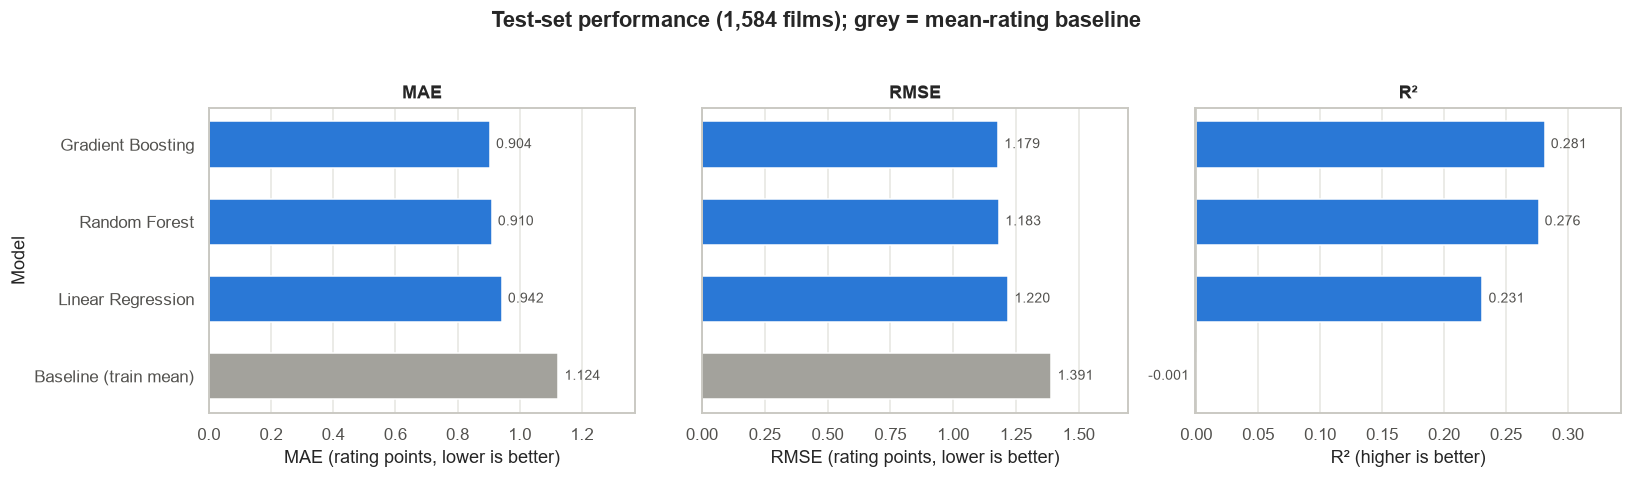

In [24]:
order = results.index.tolist()[::-1]  # best at the top of each panel
colors = [NEUTRAL if name.startswith("Baseline") else PRIMARY for name in order]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, metric, label in zip(axes, ["MAE", "RMSE", "R²"],
                             ["MAE (rating points, lower is better)", "RMSE (rating points, lower is better)",
                              "R² (higher is better)"]):
    vals = results.loc[order, metric]
    bars = ax.barh(order, vals, color=colors, height=0.6)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=4, fontsize=9, color=MUTED)
    ax.set_title(metric)
    ax.set_xlabel(label)
    ax.set_xlim(min(0, vals.min() * 1.3), vals.max() * 1.22)
    ax.axvline(0, color="#c9c8c2", linewidth=1)
    ax.grid(axis="y", visible=False)
axes[0].set_ylabel("Model")
fig.suptitle(f"Test-set performance ({len(y_test):,} films); grey = mean-rating baseline",
             fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 17. Actual vs Predicted Analysis

One panel per trained model, on identical axes. The dashed diagonal marks perfect predictions. Points above it are
over-predictions, points below it are under-predictions.

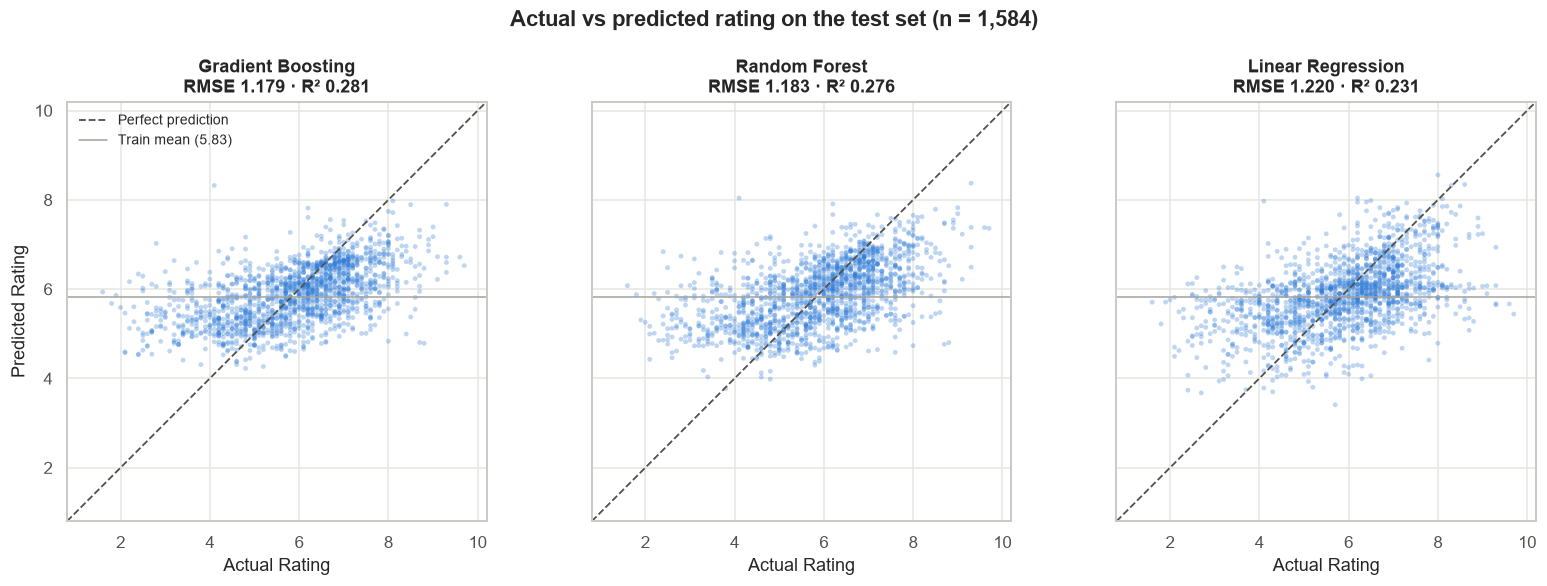

In [25]:
model_names = [n for n in results.index if not n.startswith("Baseline")]
lims = (0.8, 10.2)

fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 5), sharex=True, sharey=True)
for ax, name in zip(axes, model_names):
    pred = predictions[name]
    ax.scatter(y_test, pred, s=10, alpha=0.3, color=PRIMARY, edgecolors="none")
    ax.plot(lims, lims, linestyle="--", color=MUTED, linewidth=1.2, label="Perfect prediction")
    ax.axhline(y_train.mean(), color=NEUTRAL, linewidth=1, label=f"Train mean ({y_train.mean():.2f})")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\nRMSE {results.loc[name, 'RMSE']:.3f} · R² {results.loc[name, 'R²']:.3f}")
    ax.set_xlabel("Actual Rating")
axes[0].set_ylabel("Predicted Rating")
axes[0].legend(frameon=False, loc="upper left", fontsize=9)
fig.suptitle(f"Actual vs predicted rating on the test set (n = {len(y_test):,})", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()

In [26]:
print("Spread of predictions compared with actual ratings (test set):")
pd.DataFrame({"actual": y_test.describe(), **{n: pd.Series(predictions[n]).describe() for n in model_names}}).T[
    ["mean", "std", "min", "max"]].round(3)

Spread of predictions compared with actual ratings (test set):


,mean,std,min,max
actual,5.873,1.391,1.600,9.700
Gradient Boosting,5.874,0.643,4.225,8.323
Random Forest,5.889,0.715,3.769,8.373
Linear Regression,5.856,0.756,3.411,8.556


## 18. Residual Analysis

`residual = actual − predicted`. A positive residual means the model **under-predicted** the rating, a negative one
means it **over-predicted**.

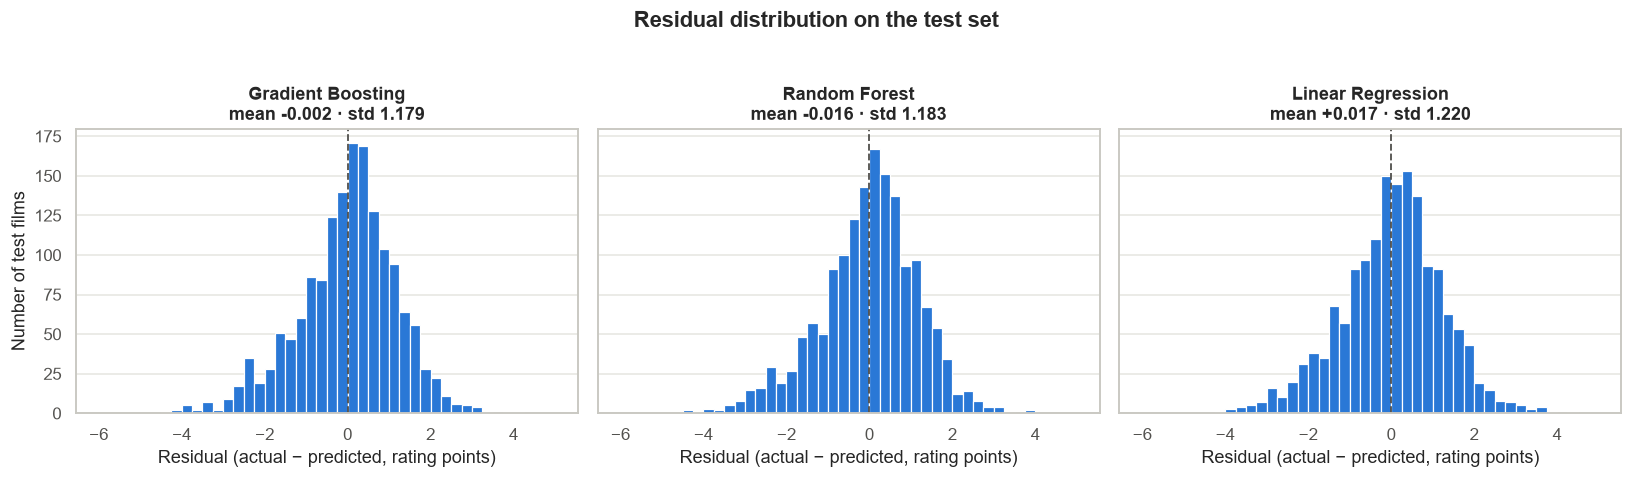

In [27]:
residuals = {n: y_test.to_numpy() - predictions[n] for n in model_names}
bins = np.arange(-6, 5.01, 0.25)

fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4.2), sharex=True, sharey=True)
for ax, name in zip(axes, model_names):
    r = residuals[name]
    ax.hist(r, bins=bins, color=PRIMARY, edgecolor="white", linewidth=0.8)
    ax.axvline(0, color=MUTED, linestyle="--", linewidth=1.2)
    ax.set_title(f"{name}\nmean {r.mean():+.3f} · std {r.std():.3f}")
    ax.set_xlabel("Residual (actual − predicted, rating points)")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Number of test films")
fig.suptitle("Residual distribution on the test set", fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_residual_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
best_resid = pd.Series(residuals[best_name], index=y_test.index)
rating_band = pd.cut(y_test, bins=[0, 4, 5, 6, 7, 8, 10], labels=["≤4", "4–5", "5–6", "6–7", "7–8", ">8"])
print(f"{best_name}: residuals by actual rating band")
pd.DataFrame({"residual": best_resid, "abs_error": best_resid.abs(), "band": rating_band}).groupby("band", observed=True).agg(
    films=("residual", "size"), mean_residual=("residual", "mean"), MAE=("abs_error", "mean")).round(3)

Gradient Boosting: residuals by actual rating band


,films,mean_residual,MAE
band,,,
≤4,166,-2.154,2.154
4–5,270,-0.865,0.894
5–6,358,-0.113,0.433
6–7,482,0.463,0.566
7–8,249,1.157,1.158
>8,59,1.989,1.989


The table shows whether errors are systematic across the rating scale. A negative mean residual for low-rated films
together with a positive one for high-rated films means predictions are pulled toward the average rating.

## 19. Error Analysis

The analysis uses the **strongest model by test RMSE** (selected in code above). Context columns come from the
modeling dataframe and the **training-fitted** transformer. `Votes` is joined **only for diagnosis**; it is not a
model input.

In [29]:
test_rows = model_df.loc[X_test.index]
errors = pd.DataFrame({
    "Name": test_rows["Name"],
    "Year": test_rows["Year"].astype("Int64"),
    "Actual Rating": y_test,
    "Predicted Rating": predictions[best_name],
    "Residual": best_resid,
    "Absolute Error": best_resid.abs(),
    "Genre": test_rows["Genre"],
    "Duration_min": test_rows["Duration_min"],
    "Director": test_rows["Director"],
    "director_train_films": Xt_test["director_count"],
    "actors_listed": Xt_test["actor_listed"],
    "lead_actor_train_films": Xt_test["actor_1_count"],
    "Votes (diagnostic only)": test_rows["Votes_eda"],
    "name_year_repeat": test_rows["name_year_repeat"],
}).sort_values("Absolute Error", ascending=False)

print(f"Model analysed: {best_name}")
errors.head(20).round(2)

Model analysed: Gradient Boosting


,Name,Year,Actual Rating,Predicted Rating,Residual,Absolute Error,Genre,Duration_min,Director,director_train_films,actors_listed,lead_actor_train_films,Votes (diagnostic only),name_year_repeat
4995,Mumbai Can Dance Saalaa,2015,1.6,5.94,-4.34,4.34,Drama,135.0,Sachindra Sharma,1,3,59,43.0,False
4209,Lahore Confidential,2021,2.8,7.03,-4.23,4.23,"Crime, Drama, Thriller",68.0,Kunal Kohli,5,3,11,522.0,False
6462,Searching for Sheela,2021,4.1,8.32,-4.22,4.22,"Documentary, Biography, Crime",58.0,Shakun Batra,2,3,0,553.0,False
4512,Main Hoon Khiladiyon Ka Khiladi,2004,8.8,4.79,4.01,4.01,Action,<NA>,K. Muralimohana Rao,9,3,12,92.0,False
6848,Student of the Year 2,2019,2.2,6.17,-3.97,3.97,"Action, Comedy, Drama",146.0,Punit Malhotra,2,3,4,17483.0,False
2899,Hari Puttar: A Comedy of Terrors,2008,1.9,5.86,-3.96,3.96,"Comedy, Drama, Family",90.0,Rajesh Bajaj,0,3,0,314.0,False
7146,The Dirty MMS,2014,2.4,6.34,-3.94,3.94,Drama,93.0,Sudhir Pillai,0,3,0,18.0,False
4568,Man on Mission Taqatwar,2005,8.7,4.81,3.89,3.89,Action,<NA>,Abbas,0,3,2,84.0,False
3127,Humshakals,2014,1.8,5.68,-3.88,3.88,"Comedy, Drama, Romance",159.0,Sajid Khan,4,3,51,7840.0,False
2310,Ek Haseena Thi Ek Deewana Tha,2017,2.5,6.29,-3.79,3.79,Drama,105.0,Suneel Darshan,7,3,0,104.0,False


To look for patterns without cherry-picking, the **top 10% largest errors** are compared with the other 90% on
attributes that describe the metadata available for each film.

In [30]:
threshold = errors["Absolute Error"].quantile(0.90)
is_large = errors["Absolute Error"] >= threshold

def profile(frame):
    return pd.Series({
        "films": len(frame),
        "mean actual rating": frame["Actual Rating"].mean(),
        "share actual ≤ 3.5 or ≥ 8.5": frame["Actual Rating"].le(3.5).mean() + frame["Actual Rating"].ge(8.5).mean(),
        "share duration missing": frame["Duration_min"].isna().mean(),
        "share duration < 80 min": frame["Duration_min"].lt(80).mean(),
        "share genre missing": frame["Genre"].isna().mean(),
        "share Documentary": frame["Genre"].str.contains("Documentary", na=False).mean(),
        "share director unseen in train": frame["director_train_films"].eq(0).mean(),
        "median director train films": frame["director_train_films"].median(),
        "median lead-actor train films": frame["lead_actor_train_films"].median(),
        "share fewer than 3 actors": frame["actors_listed"].lt(3).mean(),
        "median votes (diagnostic)": frame["Votes (diagnostic only)"].median(),
        "share votes < 20 (diagnostic)": frame["Votes (diagnostic only)"].lt(20).mean(),
        "share Name+Year repeat": frame["name_year_repeat"].mean(),
    })

pattern_table = pd.DataFrame({
    f"top 10% errors (≥ {threshold:.2f})": profile(errors[is_large]),
    "other 90%": profile(errors[~is_large]),
})
pattern_table.round(3)

,top 10% errors (≥ 1.93),other 90%
films,159.000,1425.000
mean actual rating,4.879,5.984
share actual ≤ 3.5 or ≥ 8.5,0.616,0.025
share duration missing,0.258,0.244
share duration < 80 min,0.051,0.028
share genre missing,0.025,0.013
share Documentary,0.013,0.024
share director unseen in train,0.377,0.292
median director train films,1.000,3.000
median lead-actor train films,4.000,21.000


In [31]:
votes_band = pd.cut(errors["Votes (diagnostic only)"], bins=[0, 20, 100, 1_000, np.inf],
                    labels=["5–20", "21–100", "101–1,000", "> 1,000"])
director_band = pd.cut(errors["director_train_films"], bins=[-1, 0, 2, 9, np.inf],
                       labels=["unseen (0)", "1–2", "3–9", "10+"])
print("MAE by vote-count band (diagnostic only):")
display(errors.groupby(votes_band, observed=True)["Absolute Error"].agg(films="size", MAE="mean").round(3))
print("MAE by number of training films for the director:")
display(errors.groupby(director_band, observed=True)["Absolute Error"].agg(films="size", MAE="mean").round(3))

MAE by vote-count band (diagnostic only):


,films,MAE
Votes (diagnostic only),,
5–20,462,0.886
21–100,483,0.810
"101–1,000",377,0.912
"> 1,000",262,1.099


MAE by number of training films for the director:


,films,MAE
director_train_films,,
unseen (0),476,0.996
1–2,299,0.971
3–9,461,0.891
10+,348,0.740


**Observed patterns and hypotheses** (based on the tables above; these are associations, not established causes)

- **Observed pattern: extreme ratings.** About 62% of the top-10% errors are films rated ≤ 3.5 or ≥ 8.5, against
  about 2.5% of the other films. The rating-band table shows a strongly negative mean residual for films rated ≤ 4
  and a strongly positive one above 8, and the predictions have a much smaller spread than the actual ratings.
  *Possible explanation:* the available metadata does not distinguish exceptional films from average ones, so
  predictions are pulled toward the mean.
- **Observed pattern: sparse person history.** MAE falls steadily as the director's number of training films rises,
  from about 1.0 for directors unseen in training to about 0.74 for directors with 10 or more. The median lead-actor
  training count is also much lower among the largest errors (4 vs 21). *Hypothesis for further investigation:* for
  new or rarely seen directors and actors, the count features carry little information, and the model falls back to
  genre- and year-level averages.
- **The few-votes hypothesis is not supported.** The share of films with fewer than 20 votes is almost identical in
  the two groups (≈ 28% each), and MAE is **highest** for films with more than 1,000 votes. *Possible explanation, to
  investigate:* widely seen films include heavily criticised or acclaimed releases whose ratings sit far from what
  their metadata suggests (several of the largest errors are well-known titles rated below 2.5). Votes is used here
  only for diagnosis.
- **No clear signal** for missing duration (≈ 26% vs 24%) or missing genre, which involves very small counts. None of
  the repeated Name + Year groups fell into the test set, so their effect cannot be assessed here.

## 20. Final Phase 3 Diagnostics

In [32]:
all_preds = np.column_stack([predictions[n] for n in results.index])
refit_check = dp.build_feature_transformer().fit(X_train).transform(X_test)

diagnostics = {
    "1. No NaNs in transformed training features": not Xt_train.isna().any().any(),
    "2. No NaNs in transformed test features": not Xt_test.isna().any().any(),
    "3. No infinite values (train and test)": np.isfinite(Xt_train.to_numpy(dtype=float)).all() and np.isfinite(Xt_test.to_numpy(dtype=float)).all(),
    "4. Train/test feature dimensions match": Xt_train.shape[1] == Xt_test.shape[1] and list(Xt_train.columns) == list(Xt_test.columns),
    "5. Prediction length equals test length": all(len(p) == len(y_test) for p in predictions.values()),
    "6. No group overlap": len(set(groups_train) & set(groups_test)) == 0,
    "7. Target has no missing values": not y.isna().any(),
    "8. Predictions have no NaN / infinite values": np.isfinite(all_preds).all(),
    "9. All metrics finite": np.isfinite(results.to_numpy()).all(),
    "10a. Fitted director counts equal X_train counts": director_step.name_counts_ == X_train["Director"].dropna().value_counts().to_dict(),
    "10b. Test-only directors absent from fitted stats": not (test_only_directors & set(director_step.name_counts_)),
    "10c. Refitting on X_train reproduces X_test features": refit_check.equals(Xt_test),
    "Rating / Votes not in feature inputs": not {"Rating", "Votes", "Votes_eda"} & set(X.columns),
    "Baseline constant equals training mean": bool(np.isclose(baseline.constant_[0][0], y_train.mean())),
    "Raw CSV unchanged (checksum)": file_sha256(DATA_PATH) == PHASE1_SHA256,
}
diag = pd.Series(diagnostics, name="passed").to_frame()
assert diag["passed"].all(), diag[~diag["passed"]]
diag

,passed
1. No NaNs in transformed training features,True
2. No NaNs in transformed test features,True
3. No infinite values (train and test),True
4. Train/test feature dimensions match,True
5. Prediction length equals test length,True
6. No group overlap,True
7. Target has no missing values,True
8. Predictions have no NaN / infinite values,True
9. All metrics finite,True
10a. Fitted director counts equal X_train counts,True


Check **10c** confirms the test features depend only on the training data: an independent transformer fitted on
`X_train` alone produces exactly the same test matrix as the one used for evaluation.

## 21. Phase 3 Summary

In [33]:
print("DATA AND SPLIT")
print(f"  Modeling rows              : {len(X):,}")
print(f"  Training rows / groups     : {len(X_train):,} / {groups_train.nunique():,}")
print(f"  Test rows / groups         : {len(X_test):,} / {groups_test.nunique():,}")
print(f"  Group overlap              : {len(set(groups_train) & set(groups_test))}")
print(f"  Feature matrix (train/test): {Xt_train.shape} / {Xt_test.shape}")
print("\nTEST-SET METRICS (sorted by RMSE)")
print(results.round(4).to_string())
print(f"\nStrongest initial model by test RMSE: {best_name}")
print(f"Best model per metric: {metric_leaders}")
print("\nBOOTSTRAP RMSE DIFFERENCES VS", best_name)
print(bootstrap_table.round(4).to_string())
print(f"\nAll diagnostics passed: {bool(diag['passed'].all())}")
print("Figures:", ", ".join(f for f in ["09_model_comparison.png", "10_actual_vs_predicted.png", "11_residual_distribution.png"]
                           if (FIG_DIR / f).exists()))

DATA AND SPLIT
  Modeling rows              : 7,919
  Training rows / groups     : 6,335 / 6,332
  Test rows / groups         : 1,584 / 1,584
  Group overlap              : 0
  Feature matrix (train/test): (6335, 322) / (1584, 322)

TEST-SET METRICS (sorted by RMSE)
                          MAE     MSE    RMSE      R²
Model                                                
Gradient Boosting      0.9044  1.3903  1.1791  0.2813
Random Forest          0.9101  1.3999  1.1832  0.2764
Linear Regression      0.9424  1.4876  1.2197  0.2311
Baseline (train mean)  1.1243  1.9361  1.3914 -0.0008

Strongest initial model by test RMSE: Gradient Boosting
Best model per metric: {'MAE': 'Gradient Boosting', 'MSE': 'Gradient Boosting', 'RMSE': 'Gradient Boosting', 'R²': 'Gradient Boosting'}

BOOTSTRAP RMSE DIFFERENCES VS Gradient Boosting
                       RMSE difference vs Gradient Boosting  95% CI low  95% CI high  share of resamples where it is worse
model                                       

### Interpretation

- **Every trained model beats the mean-rating baseline** on all four metrics (table in Section 15).
- **Gradient Boosting has the best value on all four metrics** in this run (selected in code by lowest test RMSE).
  However, its lead over **Random Forest is very small**: the 95% bootstrap interval for the RMSE difference
  includes 0, so the two cannot be reliably separated on this test set. Both are clearly ahead of Linear
  Regression, whose interval excludes 0.
- **Improvement over the baseline** is about 15% in RMSE and about 20% in MAE for the tree ensembles (Section 15).
- **Absolute performance is modest.** A test R² of roughly a quarter to under a third means that most of the
  variation in ratings is **not** explained by year, duration, genre, director and cast information alone.
- **Overfitting:** Random Forest fits the training data much more closely than the test data (Section 15). Gradient
  Boosting and Linear Regression show smaller gaps.
- **Systematic error:** predictions are compressed toward the average rating, so very low- and very high-rated films
  have the largest errors.

### Limitations

1. **One split.** Metrics come from a single 80/20 group split; a different seed would give somewhat different numbers.
   Group-aware cross-validation is the natural next step.
2. **No tuning.** All model parameters are initial choices; the Phase 2 frequency thresholds (10 directors, 20 actors)
   were not tuned either.
3. **Hard-to-predict extremes.** Errors are dominated by very low- and very high-rated films. The metadata-only
   features give limited information about how audiences will receive an individual film.
4. **Collinear features.** A few engineered features are exact linear combinations of others (rank check in
   Section 10). This does not affect predictions, but Linear Regression coefficients should not be interpreted
   individually.
5. **Votes excluded by design.** Whether adding `Votes` changes performance is left for the planned secondary experiment.

*No model was saved to disk, the raw CSV was not modified, and preprocessing was fitted on training data only.*